In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vtools import plot as vplt

import uncertainties as un
import uncertainties.unumpy as unp
from uncertainties.unumpy import nominal_values as nom
from uncertainties.unumpy import std_devs as std
from scipy import stats

## Load Data

In [2]:
dat = pd.read_pickle('data/vaterite_processed.pkl')

no_high_mg = (dat.solution_start['Mg/Ca'] < 3).values  # exclude high Mg point that grew aragonite
vaterite_growth = dat.overgrowth.F_V.values >= 0  # only select data where vaterite grew


## Physical Characterstics

### How does the amount of new growth change with solution chemistry?

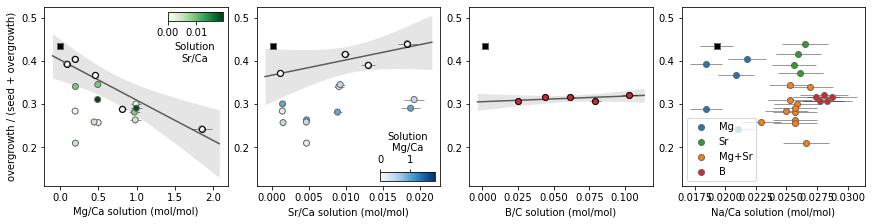

In [3]:
yvar=('derived', 'f')

fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar)
for ax in axs[1:]:
    ax.get_shared_y_axes().join(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('overgrowth / (seed + overgrowth)')

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)

### How does the amount of vaterite in the overgrowth change with solution chemistry?

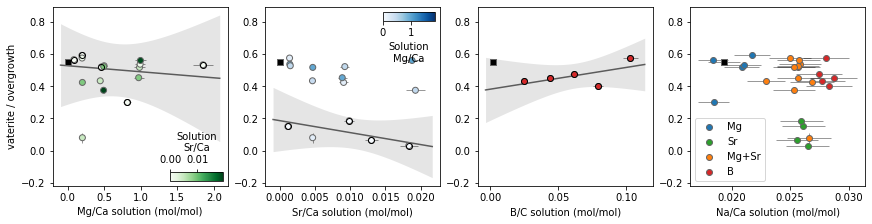

In [4]:
yvar=('overgrowth', 'F_V')
fig, axs = vplt.solution_vs_yvar(dat.loc[no_high_mg & vaterite_growth], yvar=yvar)
for ax in axs[1:]:
    ax.get_shared_y_axes().join(ax, axs[0])
    ax.set_ylabel(None)
axs[0].set_ylabel('vaterite / overgrowth');

# line of best fit for single-element experiments
for i, el in enumerate(['Mg', 'Sr', 'B']):
    denom = 'Ca'
    if el == 'B':
        denom = 'C'
    ax = axs[i]
    sub = dat.loc[no_high_mg & vaterite_growth & (dat.metadata.Experiment.isin([el]).values)]
    x = nom(sub.solution_start[f'{el}/{denom}']).ravel()
    y = nom(sub[yvar]).ravel()
    
    ax.scatter(x, y, color=(0,0,0,0), edgecolor='k', lw=1)
    p, cov = np.polyfit(x, y, 1, cov=True)
    up = un.correlated_values(p, cov)
    nx = np.linspace(*ax.get_xlim())
    pred = np.polyval(up, nx)
    ci_m = stats.t.interval(0.95, len(x) - 1)
    ax.plot(nx, nom(pred), color='k', alpha=0.6, zorder=-5)
    ax.fill_between(nx, nom(pred) + std(pred) * ci_m[0], nom(pred) + std(pred) * ci_m[1], alpha=0.1, color='k', lw=0, zorder=-5)

Vaterite fraction Mg vs Sr crossplot (with exclusions)

## Overgrowth Composition

### Overgrowth composition as a function of solution chemistry

/usr/lib/python3.10/site-packages/matplotlib/axes/_base.py:2480: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


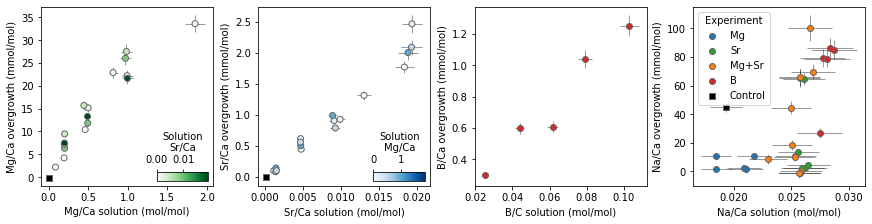

In [5]:
vplt.solution_vs_solid(dat.loc[no_high_mg], phase='overgrowth');

Plot of Sr vs. Na/Ca to explore vertical trend in RH panel above.

### Vaterite composition as a function of solution chemistry

Look at `Fractionation factor_testing for polymorph ratio_04052022` spreadsheet for calcite fractionation factors.

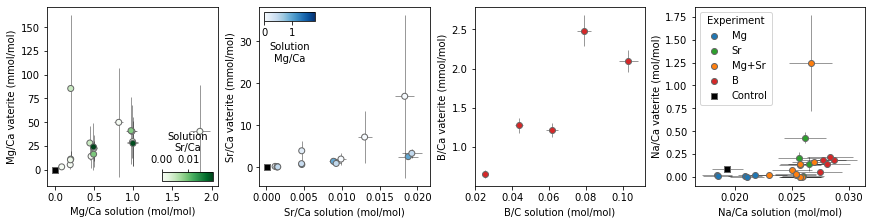

In [6]:
vplt.solution_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], phase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/C', 'Na/Ca']);

### Overgrowth vs. vaterite composition

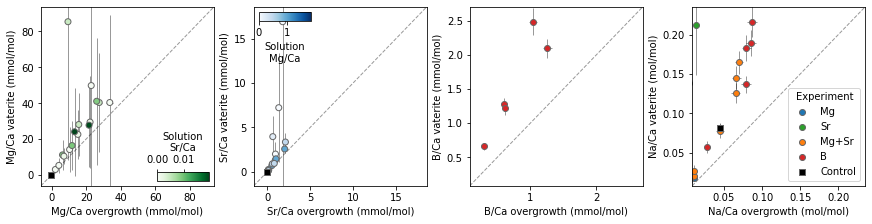

In [7]:
vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='overgrowth', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);

### Calcite vs. vaterite composition

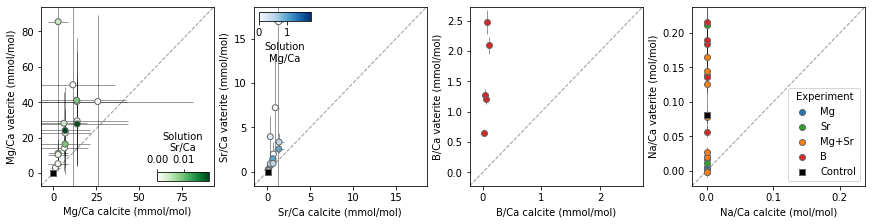

In [8]:
vplt.solid_vs_solid(dat=dat.loc[no_high_mg & vaterite_growth], xphase='calcite', yphase='vaterite', vars=['Mg/Ca', 'Sr/Ca', 'B/Ca', 'Na/Ca']);